# 07 — LC25000 data preparation (lung binary)

Discover all LC25000 images, restrict to lung tissue, label as malignant (`lung_aca` + `lung_scc`) vs benign (`lung_n`). Saves `results/histology_cache/labels.csv` for the rest of the pipeline.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import yaml

from utils.seed import set_seed
from utils.data_histology import load_lc25000, subset_lung_binary

with open('../configs/histology.yaml') as f:
    cfg = yaml.safe_load(f)
set_seed(cfg['seed'])
cfg

{'seed': 42,
 'data': {'root': '../../data/lc25000/lung_colon_image_set',
  'cache_dir': '../results/histology_cache',
  'image_size': 224,
  'task': 'lung_binary',
  'max_per_class': 1000},
 'features': {'glcm_distances': [1, 2, 3],
  'glcm_angles': [0, 0.785, 1.571, 2.356],
  'lbp_radius': 1,
  'lbp_n_points': 8,
  'color_hist_bins': 16},
 'cv': {'n_splits': 5, 'inner_splits': 3, 'scoring': 'roc_auc'},
 'dl': {'batch_size': 32,
  'epochs': 30,
  'lr': 0.0001,
  'weight_decay': 0.0001,
  'patience': 5,
  'num_workers': 4,
  'device': 'cuda'},
 'paths': {'results': '../results', 'figures': '../results/figures'}}

In [2]:
df = load_lc25000(cfg['data']['root'])
print('total images:', len(df))
df['class'].value_counts()

total images: 25000


class
lung_aca     5000
lung_n       5000
lung_scc     5000
colon_aca    5000
colon_n      5000
Name: count, dtype: int64

In [3]:
from utils.data_histology import stratified_subsample

lung = subset_lung_binary(df)
max_per_class = cfg['data'].get('max_per_class')
if max_per_class:
    lung = stratified_subsample(lung, per_class=max_per_class, seed=cfg['seed'])
    print(f'subsampled to {max_per_class}/class')

print('lung-only:', len(lung))
print('label distribution:')
print(lung['label_binary'].value_counts())
print('pos rate:', lung['label_binary'].mean())

subsampled to 1000/class
lung-only: 3000
label distribution:
label_binary
1    2000
0    1000
Name: count, dtype: int64
pos rate: 0.6666666666666666


In [4]:
cache_dir = Path('..') / cfg['data']['cache_dir']
cache_dir.mkdir(parents=True, exist_ok=True)
lung.to_csv(cache_dir / 'labels.csv', index=False)
print('saved →', cache_dir / 'labels.csv')

saved → ../../results/histology_cache/labels.csv


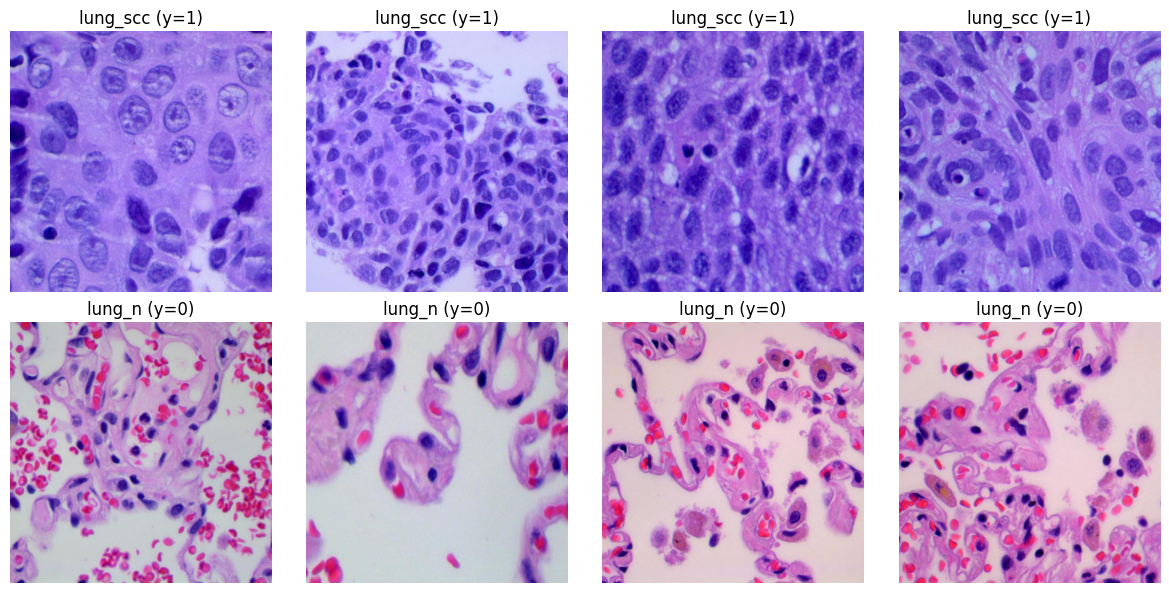

In [5]:
# Visual sanity check.
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, cls in enumerate(['lung_aca', 'lung_n', 'lung_scc']):
    sample = lung[lung['class'] == cls].sample(min(4, len(lung[lung['class'] == cls])), random_state=cfg['seed'])
    for j, (_, row) in enumerate(sample.iterrows()):
        if j >= 4: break
        ax = axes[i % 2, j]
        ax.imshow(Image.open(row['path']))
        ax.set_title(f"{row['class']} (y={row['label_binary']})"); ax.axis('off')
plt.tight_layout(); plt.show()